# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Import dataset

In [2]:
df_train = pd.read_csv('https://docs.google.com/spreadsheets/d/1JGHNU4w2cs2EEmIQZILGH0mjrBL0KL84/export?format=csv')

df_test = pd.read_csv('https://docs.google.com/spreadsheets/d/1O1lUy8hEzdA9UotI71LHBR9iPUeR2fKe/export?format=csv')

# Loading dataset

Menampilkan data awal

In [3]:
df_train.head()

,NAMA,JENIS KELAMIN,STATUS MAHASISWA,UMUR,STATUS NIKAH,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,ANIK WIDAYANTI,PEREMPUAN,BEKERJA,28,BELUM MENIKAH,"2,76","2,8","3,2","3,17","2,98",3,"3,03",0,"3,07",TERLAMBAT
1,DWI HESTYNA PRIHASTANTY,PEREMPUAN,MAHASISWA,32,BELUM MENIKAH,3,"3,3","3,14","3,14","2,84","3,13","3,25",0,"3,17",TERLAMBAT
2,MURYA ARIEF BASUKI,PEREMPUAN,BEKERJA,29,BELUM MENIKAH,"3,5","3,3","3,7","3,29","3,53","3,72","3,73",0,"3,54",TERLAMBAT
3,NANIK SUSANTI,PEREMPUAN,MAHASISWA,27,BELUM MENIKAH,"3,17","3,41","3,61","3,36","3,48","3,63","3,46",0,"3,41",TERLAMBAT
4,RIFKA ISTIQFARINA,PEREMPUAN,BEKERJA,29,BELUM MENIKAH,"2,9","2,89","3,3","2,85","2,98",3,"3,08",0,"3,09",TERLAMBAT


In [4]:
df_test.head()

,NAMA,JENIS KELAMIN,STATUS MAHASISWA,UMUR,STATUS NIKAH,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,UNAMA,LAKI - LAKI,MAHASISWA,24,BELUM MENIKAH,"3,17","2,7","3,23","2,41",3,"2,47","1,75",0,"2,75",TEPAT
1,LEYLA TRIYANA PRATIWI,PEREMPUAN,MAHASISWA,26,BELUM MENIKAH,"3,6","3,5","3,42","2,85","3,31","2,95","2,18",NaN,"3,39",TEPAT
2,VERIS SOFIYAN PRAYOGA,LAKI - LAKI,MAHASISWA,29,BELUM MENIKAH,"2,67","2,66","2,93","3,14","2,92","2,64","2,88","0,5","2,81",TEPAT
3,ADITYA AKBAR NUGRAHA,LAKI - LAKI,MAHASISWA,27,BELUM MENIKAH,"2,48","2,86","2,09","2,55","2,55","2,43","2,55","2,17","2,82",TEPAT
4,ERNA EKA RIYANTI,PEREMPUAN,MAHASISWA,25,BELUM MENIKAH,"3,19","3,08","3,31","2,83","3,36","2,73","3,06",0,"3,09",TEPAT


Mengecek Struktur Dataset

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379 entries, 0 to 378
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   NAMA              379 non-null    object
 1   JENIS KELAMIN     379 non-null    object
 2   STATUS MAHASISWA  379 non-null    object
 3   UMUR              379 non-null    int64 
 4   STATUS NIKAH      379 non-null    object
 5   IPS 1             379 non-null    object
 6   IPS 2             379 non-null    object
 7   IPS 3             379 non-null    object
 8   IPS 4             379 non-null    object
 9   IPS 5             379 non-null    object
 10  IPS 6             379 non-null    object
 11  IPS 7             379 non-null    object
 12  IPS 8             372 non-null    object
 13  IPK               376 non-null    object
 14  STATUS KELULUSAN  379 non-null    object
dtypes: int64(1), object(14)
memory usage: 44.5+ KB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   NAMA              145 non-null    object
 1   JENIS KELAMIN     145 non-null    object
 2   STATUS MAHASISWA  145 non-null    object
 3   UMUR              145 non-null    int64 
 4   STATUS NIKAH      145 non-null    object
 5   IPS 1             145 non-null    object
 6   IPS 2             145 non-null    object
 7   IPS 3             145 non-null    object
 8   IPS 4             145 non-null    object
 9   IPS 5             145 non-null    object
 10  IPS 6             145 non-null    object
 11  IPS 7             145 non-null    object
 12  IPS 8             141 non-null    object
 13  IPK               142 non-null    object
 14  STATUS KELULUSAN  145 non-null    object
dtypes: int64(1), object(14)
memory usage: 17.1+ KB


# Data Cleaning

Pemeriksaan Nilai Unik pada Kolom Kategorikal

In [7]:
print(df_train['JENIS KELAMIN'].unique())
print(df_train['STATUS MAHASISWA' ].unique())
print(df_train['STATUS NIKAH' ].unique())
print(df_train['STATUS KELULUSAN' ].unique())

['PEREMPUAN' 'LAKI - LAKI']
['BEKERJA' 'MAHASISWA']
['BELUM MENIKAH' 'MENIKAH']
['TERLAMBAT' 'TEPAT']


Menghapus Kolom yang Tidak Digunakan

In [8]:
df_train.drop(columns=['STATUS NIKAH'], inplace=True)
df_test.drop(columns=['STATUS NIKAH' ], inplace=True)

Mengubah Nilai Kategorikal menjadi Numerik

In [9]:
# Membuat dictionary untuk mengganti nilai kategorikal menjadi numerik
replacements = {
    'JENIS KELAMIN': {'LAKI - LAKI': 1, 'PEREMPUAN': 0},
    'STATUS MAHASISWA': {'MAHASISWA': 0, 'BEKERJA': 1},
    'STATUS KELULUSAN': {'TERLAMBAT': 1, 'TEPAT': 0}
}

# Melakukan encoding pada dataset training
df_train = df_train.replace(replacements, inplace=False)
df_train.head()

# Melakukan encoding pada dataset testing
df_test = df_test.replace(replacements, inplace=False)
df_test.head()

/tmp/ipython-input-4248119787.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train = df_train.replace(replacements, inplace=False)
/tmp/ipython-input-4248119787.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test = df_test.replace(replacements, inplace=False)


,NAMA,JENIS KELAMIN,STATUS MAHASISWA,UMUR,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,UNAMA,1,0,24,"3,17","2,7","3,23","2,41",3,"2,47","1,75",0,"2,75",0
1,LEYLA TRIYANA PRATIWI,0,0,26,"3,6","3,5","3,42","2,85","3,31","2,95","2,18",NaN,"3,39",0
2,VERIS SOFIYAN PRAYOGA,1,0,29,"2,67","2,66","2,93","3,14","2,92","2,64","2,88","0,5","2,81",0
3,ADITYA AKBAR NUGRAHA,1,0,27,"2,48","2,86","2,09","2,55","2,55","2,43","2,55","2,17","2,82",0
4,ERNA EKA RIYANTI,0,0,25,"3,19","3,08","3,31","2,83","3,36","2,73","3,06",0,"3,09",0


Melakukan Encoding pada Dataset Uji

In [10]:
df_train = df_train.replace(replacements, inplace=False)
df_train.head()

,NAMA,JENIS KELAMIN,STATUS MAHASISWA,UMUR,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,ANIK WIDAYANTI,0,1,28,"2,76","2,8","3,2","3,17","2,98",3,"3,03",0,"3,07",1
1,DWI HESTYNA PRIHASTANTY,0,0,32,3,"3,3","3,14","3,14","2,84","3,13","3,25",0,"3,17",1
2,MURYA ARIEF BASUKI,0,1,29,"3,5","3,3","3,7","3,29","3,53","3,72","3,73",0,"3,54",1
3,NANIK SUSANTI,0,0,27,"3,17","3,41","3,61","3,36","3,48","3,63","3,46",0,"3,41",1
4,RIFKA ISTIQFARINA,0,1,29,"2,9","2,89","3,3","2,85","2,98",3,"3,08",0,"3,09",1


In [11]:
df_test = df_test.replace(replacements, inplace=False)
df_test.head()

,NAMA,JENIS KELAMIN,STATUS MAHASISWA,UMUR,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,UNAMA,1,0,24,"3,17","2,7","3,23","2,41",3,"2,47","1,75",0,"2,75",0
1,LEYLA TRIYANA PRATIWI,0,0,26,"3,6","3,5","3,42","2,85","3,31","2,95","2,18",NaN,"3,39",0
2,VERIS SOFIYAN PRAYOGA,1,0,29,"2,67","2,66","2,93","3,14","2,92","2,64","2,88","0,5","2,81",0
3,ADITYA AKBAR NUGRAHA,1,0,27,"2,48","2,86","2,09","2,55","2,55","2,43","2,55","2,17","2,82",0
4,ERNA EKA RIYANTI,0,0,25,"3,19","3,08","3,31","2,83","3,36","2,73","3,06",0,"3,09",0


# Cek Missing Value

In [12]:
df_train.isnull().sum()

,0
NAMA,0
JENIS KELAMIN,0
STATUS MAHASISWA,0
UMUR,0
IPS 1,0
IPS 2,0
IPS 3,0
IPS 4,0
IPS 5,0
IPS 6,0


In [13]:
df_test.isnull().sum()

,0
NAMA,0
JENIS KELAMIN,0
STATUS MAHASISWA,0
UMUR,0
IPS 1,0
IPS 2,0
IPS 3,0
IPS 4,0
IPS 5,0
IPS 6,0


Menangani missing value

In [14]:
# Menangani missing value pada dataset training
df_train = df_train.dropna(subset=['IPS 8'])
df_train = df_train.dropna(subset=['IPK '])

# Menangani missing value pada dataset testing
df_test = df_test.dropna(subset=['IPS 8'])
df_test = df_test.dropna(subset=['IPK '])

Mengecek Kembali Missing Value

In [15]:
df_train.isnull().sum()

,0
NAMA,0
JENIS KELAMIN,0
STATUS MAHASISWA,0
UMUR,0
IPS 1,0
IPS 2,0
IPS 3,0
IPS 4,0
IPS 5,0
IPS 6,0


In [16]:
df_test.isnull().sum()

,0
NAMA,0
JENIS KELAMIN,0
STATUS MAHASISWA,0
UMUR,0
IPS 1,0
IPS 2,0
IPS 3,0
IPS 4,0
IPS 5,0
IPS 6,0


Menghapus Kolom yang Tidak Digunakan dalam Analisis

In [17]:
df_train = df_train.drop(columns=['NAMA'])
df_test = df_test.drop(columns=['NAMA'])

In [18]:
df_train.head()

,JENIS KELAMIN,STATUS MAHASISWA,UMUR,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,0,1,28,"2,76","2,8","3,2","3,17","2,98",3,"3,03",0,"3,07",1
1,0,0,32,3,"3,3","3,14","3,14","2,84","3,13","3,25",0,"3,17",1
2,0,1,29,"3,5","3,3","3,7","3,29","3,53","3,72","3,73",0,"3,54",1
3,0,0,27,"3,17","3,41","3,61","3,36","3,48","3,63","3,46",0,"3,41",1
4,0,1,29,"2,9","2,89","3,3","2,85","2,98",3,"3,08",0,"3,09",1


In [19]:
df_test.head()

,JENIS KELAMIN,STATUS MAHASISWA,UMUR,IPS 1,IPS 2,IPS 3,IPS 4,IPS 5,IPS 6,IPS 7,IPS 8,IPK,STATUS KELULUSAN
0,1,0,24,"3,17","2,7","3,23","2,41",3,"2,47","1,75",0,"2,75",0
2,1,0,29,"2,67","2,66","2,93","3,14","2,92","2,64","2,88","0,5","2,81",0
3,1,0,27,"2,48","2,86","2,09","2,55","2,55","2,43","2,55","2,17","2,82",0
4,0,0,25,"3,19","3,08","3,31","2,83","3,36","2,73","3,06",0,"3,09",0
5,1,0,24,"3,1","2,98","3,17","3,25","3,41","3,08","3,43",3,"3,23",0


Ubah semua string numerik menjadi float

In [20]:
# Semua string numerik dengan koma diubah menjadi float
def convert_numeric(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.')
            df[col] = pd.to_numeric(df[col], errors='coerce')  # gagal → NaN
    return df

df_train_clean = convert_numeric(df_train.copy())
df_test_clean = convert_numeric(df_test.copy())

# Analisis Korelasi FiturAnalisis Korelasi Fitur

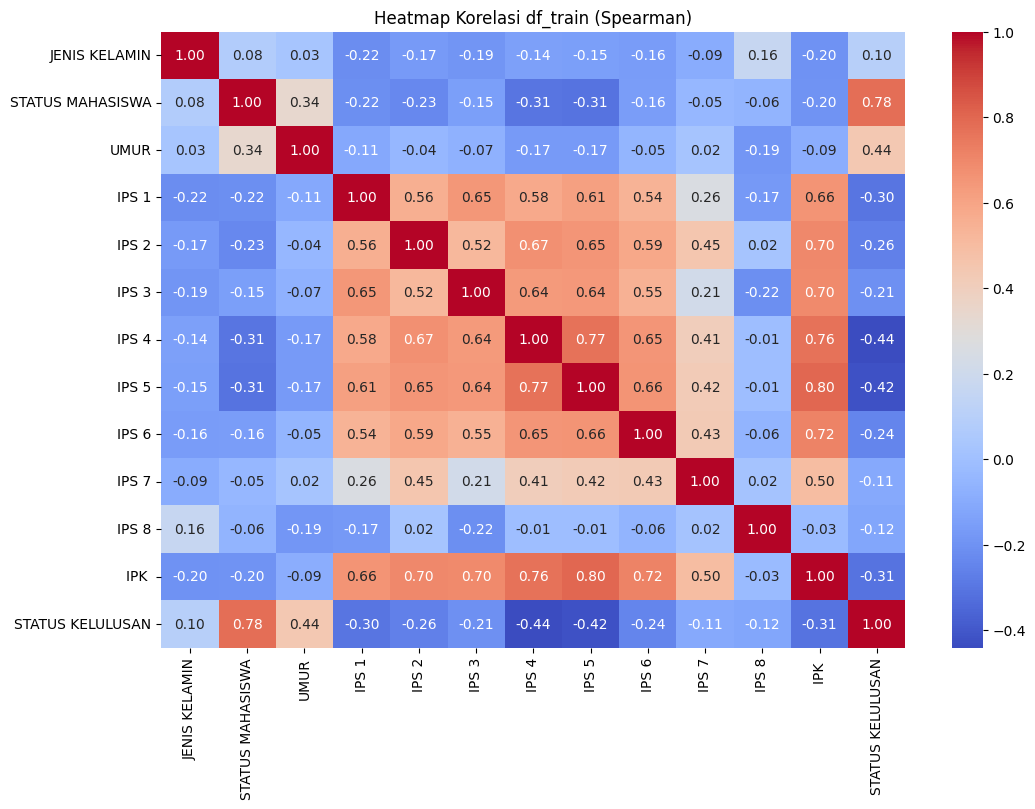

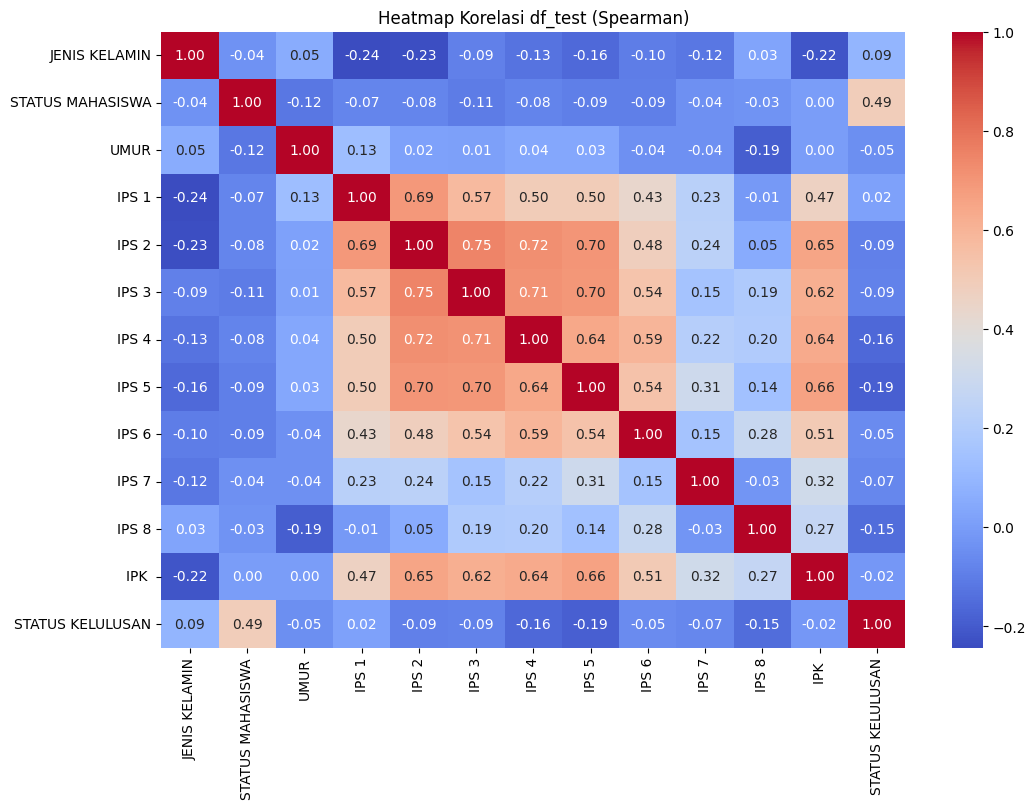

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung korelasi Spearman
correlation_matrix_train = df_train_clean.corr(method='spearman')
correlation_matrix_test = df_test_clean.corr(method='spearman')

# Heatmap untuk df_train
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_train, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi df_train (Spearman)")
plt.show()

# Heatmap untuk df_test
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_test, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi df_test (Spearman)")
plt.show()

# Visualisasi Distribusi Status Kelulusan

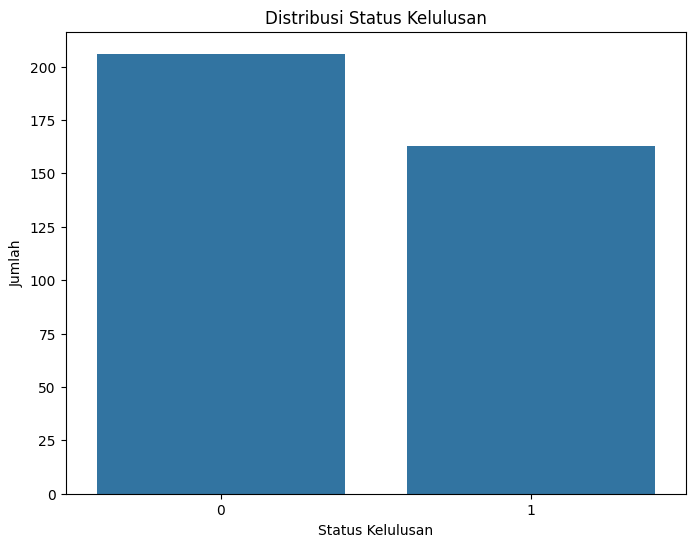

In [22]:
# Membuat diagram batang untuk status kelulusan
plt.figure(figsize=(8, 6))
sns.countplot(x='STATUS KELULUSAN', data=df_train)

# Menambahkan judul dan label
plt.title('Distribusi Status Kelulusan')
plt.xlabel('Status Kelulusan')
plt.ylabel('Jumlah')

# Menampilkan plot
plt.show()

# Modelling

Pisahkan Fitur & Label

In [23]:
# Fitur & label
x_train = df_train_clean.drop(columns=['STATUS KELULUSAN']).select_dtypes(include=['float64', 'int64'])
y_train = df_train_clean['STATUS KELULUSAN']

x_test = df_test_clean.drop(columns=['STATUS KELULUSAN']).select_dtypes(include=['float64', 'int64'])
y_test = df_test_clean['STATUS KELULUSAN']

Normalisasi Fitur

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Menangani Imbalance (SMOTE)

In [25]:
from imblearn.over_sampling import SMOTE
import numpy as np

print("Before SMOTE:")
print(y_train.value_counts())

sm = SMOTE(random_state=42, k_neighbors=1)
x_train_smote, y_train_smote = sm.fit_resample(x_train_scaled, y_train)

# Convert label ke numpy array 1D supaya aman untuk modeling
y_train_smote = np.array(y_train_smote).flatten()

print("After SMOTE:")
from collections import Counter
print(Counter(y_train_smote))


Before SMOTE:
STATUS KELULUSAN
0    206
1    163
Name: count, dtype: int64
After SMOTE:
Counter({np.int64(1): 206, np.int64(0): 206})


Hyperparameter Tuning (GridSearchCV)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(x_train_smote, y_train_smote)

print("Best Params:", grid.best_params_)
print("Best Score (CV):", grid.best_score_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'distance'}
Best Score (CV): 0.9029973552747576


Training KNN dengan parameter terbaik

In [27]:
best_knn = grid.best_estimator_
best_knn.fit(x_train_smote, y_train_smote)

KNeighborsClassifier(metric='manhattan', n_neighbors=19, weights='distance')

Evaluasi

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_knn.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[136   0]
 [  0   2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       136
           1       1.00      1.00      1.00         2

    accuracy                           1.00       138
   macro avg       1.00      1.00      1.00       138
weighted avg       1.00      1.00      1.00       138



# Evaluasi dengan Confusion Matrix

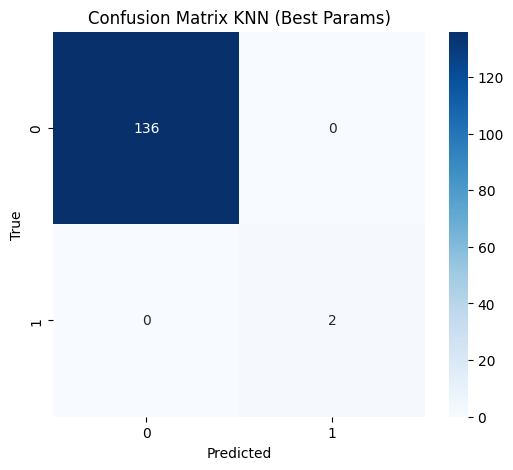

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Validasi Model dengan Cross Validation

In [30]:
cv_scores = cross_val_score(best_knn, x_train_smote, y_train_smote, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation Accuracy: 0.9029973552747576
Std Dev: 0.042371318661662674


# Menentukan Nilai K Optimal dengan Elbow Method

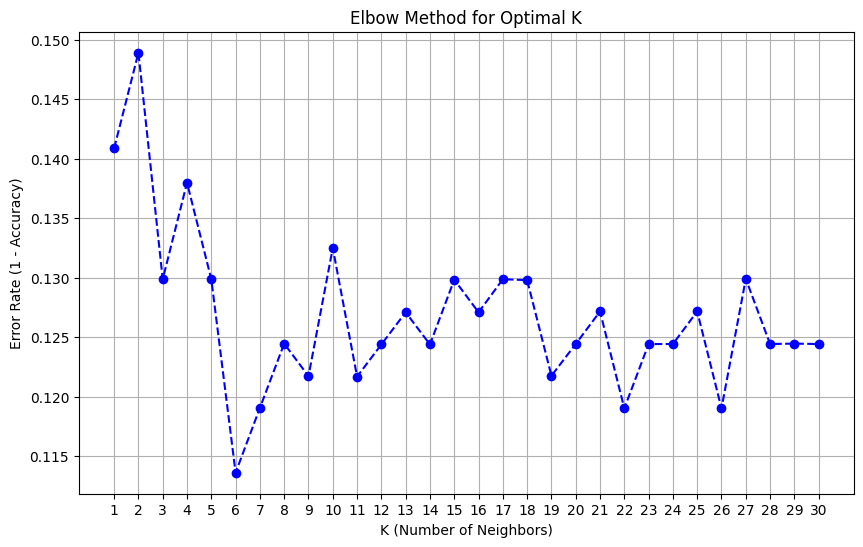

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Range nilai K yang akan diuji
k_range = range(1, 31)
cv_scores = []

# Cross validation untuk tiap K
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, x_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Error = 1 - accuracy
error_rate = [1 - x for x in cv_scores]

# Plot Elbow Method
plt.figure(figsize=(10,6))
plt.plot(k_range, error_rate, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate (1 - Accuracy)')
plt.xticks(k_range)
plt.grid(True)
plt.show()